# 1. Config 파일 읽기, WandB 연결, 데이터 다운로드

In [ ]:
# config 파일 불러오기
import yaml

# 손가락뼈 모델 config
# with open('finger_config.yaml', 'r', encoding='utf-8') as f:
#     config = yaml.safe_load(f)

# 손목뼈 모델 config
with open('wrist_config.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# 팔뼈 모델 config
# with open('arm_config.yaml', 'r', encoding='utf-8') as f:
#     config = yaml.safe_load(f)

In [ ]:
# # 구글 드라이브에 있는 데이터 파일을 코랩 로컬 드라이브에 올리기 (코랩 전용 코드)
# from google.colab import drive
# import os

# drive.mount('/content/drive')
# project_path = config['data']['project_root']

# # tar.gz 형식 압축 해제
# !tar -zxf "{project_path}/new_train.tar.gz" -C /content/
# !tar -zxf "{project_path}/new_valid.tar.gz" -C /content/

# # 구글 드라이브에 있는 py 모듈 파일을 코랩 로컬 드라이브에 복사하기 (코랩 전용 코드)
# !cp "{project_path}/loss.py"        /content/loss.py
# !cp "{project_path}/model.py"       /content/model.py
# !cp "{project_path}/optimizer.py"   /content/optimizer.py
# !cp "{project_path}/trainer.py"     /content/trainer.py
# !cp -r "{project_path}/utils"       /content/utils

In [ ]:
# WandB 연결
import os, wandb
from google.colab import userdata
from utils.setting import wandb_start

os.environ["WANDB_API_KEY"] = userdata.get('WANDB_API_KEY')
wandb.login()

wandb_run = wandb_start(config)

# 2. 라이브러리 import

In [ ]:
# 프로젝트에 필요한 라이브러리 설치
# !pip install opencv-python-headless
# !pip install pandas
# !pip install scikit-learn
# !pip install albumentations
# !pip install matplotlib
!pip install -q monai

In [ ]:
# 라이브러리 import
# python native
import os
import json
import random
import datetime
from functools import partial

# external library
import cv2
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import GroupKFold
import albumentations as A

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models

# optimization
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR, CosineAnnealingWarmRestarts

# visualization
import matplotlib.pyplot as plt

# loss dict
from collections import Counter
import monai

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


In [ ]:
# 랜덤 시드 설정 및 모델 저장 위치 지정
from utils.setting import set_seed

RANDOM_SEED = config['other']['seed']
SAVED_DIR = config['checkpoint']['dir']

if not os.path.exists(SAVED_DIR):
    os.makedirs(SAVED_DIR)

set_seed(RANDOM_SEED)

def worker_init_fn(worker_id):
    seed = RANDOM_SEED + worker_id
    np.random.seed(seed)
    random.seed(seed)

In [ ]:
# 시각화를 위해 클래스 정보 준비
CLASSES = config['classes']
CLASS2IND = {v: i for i, v in enumerate(CLASSES)}
IND2CLASS = {v: k for k, v in CLASS2IND.items()}

# 3. 데이터 준비

In [ ]:
from utils.dataset import get_data, get_transforms, XRayDataset
from utils.visualization import label2rgb
from utils.setting import get_class_index

# 훈련 이미지 및 라벨 640쌍, 검증 이미지 및 라벨 160쌍
TRAIN_IMAGE_ROOT = config['data']['train_image_root']
TRAIN_LABEL_ROOT = config['data']['train_label_root']

VALID_IMAGE_ROOT = config['data']['valid_image_root']
VALID_LABEL_ROOT = config['data']['valid_label_root']

train_images = get_data(TRAIN_IMAGE_ROOT, ".png")
train_labels = get_data(TRAIN_LABEL_ROOT, ".json")
valid_images = get_data(VALID_IMAGE_ROOT, ".png")
valid_labels = get_data(VALID_LABEL_ROOT, ".json")

train_images = sorted(train_images)
train_labels = sorted(train_labels)

valid_images = sorted(valid_images)
valid_labels = sorted(valid_labels)

print(f"훈련 이미지: {len(train_images)}장, 훈련 라벨: {len(train_labels)}장")
print(f"훈련 이미지: {len(valid_images)}장, 훈련 라벨: {len(valid_labels)}장")

훈련 이미지: 640장, 훈련 라벨: 640장
훈련 이미지: 160장, 훈련 라벨: 160장


In [ ]:
# 증강 및 dataset 설정
class_index = list(range(len(CLASSES)))

train_transform = get_transforms(config, is_train=True)
valid_transform = get_transforms(config, is_train=False)

train_dataset = XRayDataset(train_images, train_labels, TRAIN_IMAGE_ROOT, TRAIN_LABEL_ROOT, class_index, CLASS2IND, is_train=True, transform=train_transform)
valid_dataset = XRayDataset(valid_images, valid_labels, VALID_IMAGE_ROOT, VALID_LABEL_ROOT, class_index, CLASS2IND, is_train=False, transform=valid_transform)

image, label = train_dataset[0]
print(f"훈련 이미지 사이즈: {image.shape}, 훈련 라벨 사이즈: {label.shape}")

image, label = valid_dataset[0]
print(f"검증 이미지 사이즈: {image.shape}, 검증 라벨 사이즈: {label.shape}")

print(f"이미지 데이터 타입: {image.dtype}, 라벨 데이터 타입: {image.dtype}")

Horizontal flip 적용
Affine 적용
Normalize 적용
Normalize 적용
훈련 이미지 사이즈: torch.Size([3, 512, 512]), 훈련 라벨 사이즈: torch.Size([8, 512, 512])
검증 이미지 사이즈: torch.Size([3, 512, 512]), 검증 라벨 사이즈: torch.Size([8, 512, 512])
이미지 데이터 타입: torch.float32, 라벨 데이터 타입: torch.float32


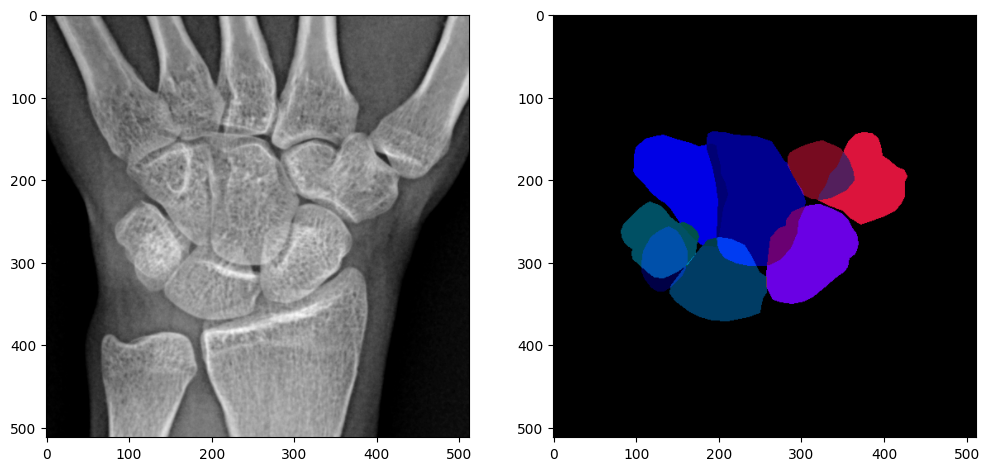

In [ ]:
# 훈련 이미지, 라벨 잠깐 보고 가기
image, label = train_dataset[0]

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(image[0], cmap='gray')
ax[1].imshow(label2rgb(label), cmap='gray')

plt.show()

In [ ]:
# dataloader 설정
TRAIN_BATCH_SIZE = config['train']['batch_size']
VALID_BATCH_SIZE = config['valid']['batch_size']

TRAIN_NUM_WORKERS = config['train']['num_workers']
VALID_NUM_WORKERS = config['train']['num_workers']

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    num_workers=TRAIN_NUM_WORKERS,
    worker_init_fn=worker_init_fn,
    drop_last=True
    )

valid_loader = DataLoader(
    dataset=valid_dataset,
    batch_size=VALID_BATCH_SIZE,
    shuffle=False,
    num_workers=VALID_NUM_WORKERS,
    worker_init_fn=worker_init_fn,
    drop_last=False
    )

print(f"에포크당 배치 수: 훈련 {len(train_loader)}개, 검증 {len(valid_loader)}개")

에포크당 배치 수: 훈련 80개, 검증 20개


# 4. 학습 설정

In [ ]:
# 세그멘테이션 모델 library download 하기
!pip install -q git+https://github.com/qubvel/segmentation_models.pytorch

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from loss import get_loss_list
from model import get_model
from optimizer import get_optimizer, get_scheduler
from trainer import train

loss_config  = config['loss']
model_config = config['model']
optim_config = config['optimizer']
target_class = config['data']['target_class']

model     = get_model(model_config, target_class)
optimizer = get_optimizer(model, optim_config)
scheduler = get_scheduler(config, optimizer, len(train_loader))
loss_list = get_loss_list(loss_config)

train_config = {
    'accum_step':   config['train']['gradient_accum'],
    'num_epochs':   config['train']['epoch'],
    'val_every':    config['valid']['epoch'],
    'threshold':    config['valid']['threshold'],
    'classes':      [config['classes'][i] for i in class_index],
    'saved_dir':    config['checkpoint']['dir'],
    'saved_name':   config['checkpoint']['model_name'],
    'warmup_epoch': config['scheduler']['warmup_epoch']
}

학습 모델: UnetPlusPlus + tu-hrnet_w48
옵티마이저 설정: AdamW, lr={'encoder': '1e-3', 'decoder': '1e-3', 'head': '1e-3'}
스케줄러 적용: LinearLR, 1 에폭
스케줄러 적용: Cosine Annealing 50 에폭
손실 함수 적용: smooth_bce


# 5. 훈련 시작

In [ ]:
train(model,
      train_loader,
      valid_loader,
      loss_list,
      optimizer,
      scheduler,
      train_config)

In [ ]:
wandb.finish()

# 모델의 검증 데이터 추론 결과 저장

In [ ]:
from PIL import Image
SAVED_DIR = config['checkpoint']['dir']
model_name = config['checkpoint']['model_name']

model = torch.load(os.path.join(SAVED_DIR, model_name), weights_only=False)
# model = torch.load('/content/finger_260103_실험6_best.pt', weights_only=False)

target_class = config['data']['target_class']

In [ ]:
experiment_date = 260106
experiment_num = '1'
edge_enhance_option = 0

for thr in range(1, 10):
    thr = thr / 10

    output_dir = config['data']['valid_output_root']
    output_dir = os.path.join(output_dir, f"thr{thr}")
    os.makedirs(output_dir, exist_ok=True)

    output_dict = {}

    model.eval()
    with torch.no_grad():
        for i, (image, label) in enumerate(valid_dataset):
            image_name = f"output_{i:03d}"
            output_dict[image_name] = {}

            image = image.cuda().unsqueeze(0)
            output = model(image)

            output_h, output_w = output.size(-2), output.size(-1)
            label_h, label_w = label.size(-2), label.size(-1)

            if output_h != label_h or output_w != label_w:
                output = F.interpolate(output, size=(label_h, label_w), mode="bilinear")

            pred = torch.sigmoid(output.squeeze(0))
            pred = (pred > thr).byte()
            label = label.byte().cuda()

            # 내 작은 야심작 edge enhancer
            if edge_enhance_option:
                edge_path = f"./new_valid/btd_image/{target_class}/{target_class}_{i:03d}.png"
                edge_enhancer = cv2.imread(edge_path, cv2.IMREAD_GRAYSCALE)                     # (H,W)
                edge_enhancer = torch.from_numpy(edge_enhancer).unsqueeze(dim=0).cuda()         # (1,H,W)
                edge_enhancer = (edge_enhancer != 0).byte()                                     # binary mask

                pred = pred * edge_enhancer    # (C,H,W), enhacned_pred

            TP_map = ((pred==1) & (label==1)).byte()    # (C,H,W)
            TN_map = ((pred==0) & (label==0)).byte()
            FP_map = ((pred==1) & (label==0)).byte()
            FN_map = ((pred==0) & (label==1)).byte()

            TP = TP_map.flatten(start_dim=-2).sum(dim=-1)   # (C,H,W) -> (C,H*W) -> (C)
            TN = TN_map.flatten(start_dim=-2).sum(dim=-1)
            FP = FP_map.flatten(start_dim=-2).sum(dim=-1)
            FN = FN_map.flatten(start_dim=-2).sum(dim=-1)
            dice = (2 * TP) / (2 * TP + FP + FN)
            mean_dice = dice.mean()

            for class_idx in range(len(CLASSES)):
                output_dict[image_name]['mean_dice'] = mean_dice.item()
                output_dict[image_name][class_idx] = {'dice': dice[class_idx].item(),
                                                    'TP': TP[class_idx].item(),
                                                    'TN': TN[class_idx].item(),
                                                    'FP': FP[class_idx].item(),
                                                    'FN': FN[class_idx].item()}
            FP_color_map = label2rgb(FP_map.cpu())
            FN_color_map = label2rgb(FN_map.cpu())

            FP_color_map = Image.fromarray(FP_color_map)
            FN_color_map = Image.fromarray(FN_color_map)

            FP_output_path = os.path.join(output_dir, image_name+"_FP.png")
            FN_output_path = os.path.join(output_dir, image_name+"_FN.png")

            FP_color_map.save(FP_output_path)
            FN_color_map.save(FN_output_path)

            print(f"Saved {i}")

    with open(f'{experiment_date}_{experiment_num}_thr{thr}_{target_class}_output.json', 'w', encoding='utf-8') as f:
        json.dump(output_dict, f, indent=4)


In [ ]:
# output 파일 압축 코드 (코랩에서 다운로드 받을 때 사용)
!tar -zcvf 260106_1_arm_output.tar.gz ./260106_1_arm_output

# output 파일 압축 해제 코드
# !tar -zxf "output.tar.gz"

In [ ]:
# output 파일 지우는 용도
import shutil

folder_path = './260106_1_arm_output'
shutil.rmtree(folder_path)

# 앙상블

In [ ]:
from PIL import Image
from utils.performance import dice_coef

UppHR48 = torch.load('/content/wrist_260105_실험3_best.pt', weights_only=False)
Segb3_1 = torch.load('/content/wrist_260106_실험1.pt', weights_only=False)
Segb3_2 = torch.load('/content/wrist_260106_실험2.pt', weights_only=False)

UppHR48.eval()
Segb3_1.eval()
Segb3_1.eval()

In [ ]:
best_mean_dice = 0
best_threshold = 0

for i in range(1,10):
    thr = i / 10
    dices = []

    with torch.no_grad():
        for i, (image, label) in tqdm(enumerate(valid_dataset), total=len(valid_dataset)):

            image = image.cuda().unsqueeze(0)
            hr_output = UppHR48(image)
            sg1_output = Segb3_1(image).logits
            sg2_output = Segb3_2(image)

            sg1_output = F.interpolate(sg1_output, size=(512, 512), mode="bilinear")

            # print(hr_output.shape, sg1_output.shape, sg2_output.shape)

            hr_pred = torch.sigmoid(hr_output.squeeze(0))
            sg1_pred = torch.sigmoid(sg1_output.squeeze(0))
            sg2_pred = torch.sigmoid(sg2_output.squeeze(0))

            # # 단순 평균
            hr_weight = 0.5
            sg1_weight = 0.25
            sg2_weight = 0.25
            pred = hr_weight*hr_pred + sg1_weight*sg1_pred + sg2_weight*sg2_pred

            # # 하드 보팅 (다수결)
            # hr_pred   = (hr_pred > thr).byte()
            # sg1_pred  = (sg1_pred > thr).byte()
            # sg2_pred  = (sg2_pred > thr).byte()
            # pred = ((hr_pred + sg1_pred + sg2_pred) > 1).byte()

            pred = (pred > thr).byte()
            label = label.byte().cuda()

            TP_map = ((pred==1) & (label==1)).byte()    # (C,H,W)
            TN_map = ((pred==0) & (label==0)).byte()
            FP_map = ((pred==1) & (label==0)).byte()
            FN_map = ((pred==0) & (label==1)).byte()

            TP = TP_map.flatten(start_dim=-2).sum(dim=-1)   # (C,H,W) -> (C,H*W) -> (C)
            TN = TN_map.flatten(start_dim=-2).sum(dim=-1)
            FP = FP_map.flatten(start_dim=-2).sum(dim=-1)
            FN = FN_map.flatten(start_dim=-2).sum(dim=-1)
            dice = (2 * TP) / (2 * TP + FP + FN)

            dices.append(dice)

    dices = torch.stack(dices, 0)
    dices = dices.mean(dim=0).mean()

    if dices > best_mean_dice:
        best_mean_dice = dices
        best_threshold = thr
        print(best_mean_dice, best_threshold)

print(best_mean_dice, best_threshold)
